# Análisis Rápido de Sentimientos con Insights Accionables
## Versión optimizada para reseñas de cafetería

Este notebook realiza un análisis de sentimientos basado en aspectos (ABSA) para extraer insights específicos y accionables de las reseñas de clientes.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
from collections import Counter, defaultdict
import json

# Análisis de sentimientos básico
from textblob import TextBlob

warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Definición de la clase analizadora

In [2]:
class SimpleCafeAnalyzer:
    """Analizador avanzado y específico para reseñas de cafetería"""

    def __init__(self):
        """Inicializar configuraciones expandidas y mejoradas"""

        # Aspectos del negocio (EXPANDIDO)
        self.aspects = {
            'coffee': ['coffee', 'espresso', 'cappuccino', 'latte', 'americano', 'mocha', 'brew',
                      'macchiato', 'cortado', 'flat white', 'ristretto', 'lungo', 'decaf', 'iced coffee',
                      'cold brew', 'foam', 'milk', 'barista', 'caffeine', 'roast', 'beans'],

            'food': ['food', 'sandwich', 'pastry', 'cake', 'breakfast', 'lunch', 'croissant', 'toast',
                    'avocado', 'eggs', 'bacon', 'pancake', 'waffle', 'bagel', 'muffin', 'cookie',
                    'salad', 'soup', 'wrap', 'panini', 'quiche', 'tart', 'brownie', 'donut',
                    'granola', 'yogurt', 'fruit', 'bowl', 'smoothie', 'juice', 'brunch', 'snack',
                    'dessert', 'tapas', 'tortilla', 'bocadillo', 'tostada', 'portion', 'plate'],

            'service': ['service', 'staff', 'waiter', 'waitress', 'barista', 'employee', 'serve',
                       'attention', 'attentive', 'helpful', 'professional', 'friendly', 'polite',
                       'efficient', 'quick', 'slow', 'fast', 'speed', 'order', 'wait', 'queue',
                       'treat', 'attitude', 'smile', 'welcome', 'greeting', 'management', 'team'],

            'atmosphere': ['atmosphere', 'ambience', 'environment', 'decor', 'music', 'cozy', 'vibe',
                          'comfortable', 'relaxing', 'quiet', 'loud', 'noisy', 'peaceful', 'busy',
                          'crowded', 'spacious', 'intimate', 'modern', 'traditional', 'authentic',
                          'trendy', 'hipster', 'classic', 'elegant', 'casual', 'romantic', 'family',
                          'chairs', 'tables', 'seating', 'furniture', 'lighting', 'design', 'interior',
                          'outdoor', 'terrace', 'patio', 'garden', 'view', 'window', 'decoration'],

            'price': ['price', 'cost', 'expensive', 'cheap', 'affordable', 'value', 'money', 'worth',
                     'overpriced', 'reasonable', 'fair', 'budget', 'premium', 'quality-price',
                     'bill', 'charge', 'pay', 'euro', 'dollar', 'pound', 'tip', 'discount', 'offer',
                     'deal', 'promotion', 'free', 'complimentary', 'included'],

            'location': ['location', 'parking', 'access', 'convenient', 'near', 'far', 'area',
                        'neighborhood', 'street', 'corner', 'plaza', 'square', 'metro', 'bus',
                        'station', 'walk', 'distance', 'central', 'tourist', 'local', 'hidden',
                        'easy to find', 'hard to find', 'sol', 'atocha', 'caixa', 'forum', 'prado',
                        'museum', 'downtown', 'city center', 'accessible', 'transport'],

            'cleanliness': ['clean', 'dirty', 'hygiene', 'tidy', 'bathroom', 'toilet', 'table',
                           'spotless', 'immaculate', 'filthy', 'messy', 'organized', 'maintained',
                           'sanitary', 'wash', 'wipe', 'sweep', 'fresh', 'neat', 'orderly'],

            'beverages': ['tea', 'juice', 'smoothie', 'shake', 'water', 'soda', 'beer', 'wine',
                         'cocktail', 'hot chocolate', 'chai', 'matcha', 'infusion', 'drink',
                         'beverage', 'refreshment', 'ice', 'iced', 'hot', 'cold', 'temperature'],

            'timing': ['hours', 'schedule', 'open', 'closed', 'closing', 'opening', 'early', 'late',
                      'morning', 'afternoon', 'evening', 'weekend', 'weekday', 'monday', 'tuesday',
                      'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'holiday', 'time'],

            'technology': ['wifi', 'internet', 'laptop', 'work', 'study', 'plug', 'outlet', 'charge',
                          'computer', 'phone', 'digital', 'online', 'app', 'order online', 'delivery']
        }

        # Problemas específicos por categoría (MUY EXPANDIDO Y ESPECÍFICO)
        self.aspect_specific_problems = {
            'coffee': {
                'burnt_coffee': ['burnt', 'burned', 'bitter', 'over-roasted', 'charred'],
                'watery_coffee': ['watery', 'weak', 'diluted', 'thin', 'no flavor'],
                'cold_coffee': ['cold coffee', 'lukewarm coffee', 'not hot coffee'],
                'bad_foam': ['no foam', 'bad foam', 'flat', 'no crema', 'milk separated'],
                'wrong_order': ['wrong coffee', 'not what i ordered', 'mistake order'],
                'bad_beans': ['bad beans', 'stale coffee', 'old coffee', 'cheap coffee'],
                'too_sweet': ['too sweet', 'too much sugar', 'sugary'],
                'no_options': ['no decaf', 'no alternatives', 'limited coffee menu']
            },
            'food': {
                'stale_food': ['stale', 'not fresh', 'old', 'day old', 'yesterday'],
                'cold_food': ['cold food', 'not heated', 'frozen inside', 'lukewarm food'],
                'small_portions': ['small portion', 'tiny', 'not enough food', 'still hungry'],
                'limited_menu': ['limited menu', 'no options', 'few choices', 'boring menu'],
                'no_vegetarian': ['no vegetarian', 'no vegan', 'no gluten free', 'no healthy'],
                'overcooked': ['overcooked', 'burned food', 'dry', 'hard', 'tough'],
                'undercooked': ['undercooked', 'raw', 'not cooked', 'pink inside'],
                'poor_presentation': ['ugly', 'bad presentation', 'messy plate', 'sloppy'],
                'wrong_ingredients': ['missing ingredients', 'wrong filling', 'not as described']
            },
            'service': {
                'slow_service': ['slow', 'wait forever', 'long wait', 'took ages', 'hours'],
                'rude_staff': ['rude', 'unfriendly', 'impolite', 'mean', 'nasty', 'arrogant'],
                'ignored': ['ignored', 'invisible', 'not attended', 'forgotten', 'no attention'],
                'unprofessional': ['unprofessional', 'incompetent', 'untrained', 'amateur'],
                'wrong_order': ['wrong order', 'mistake', 'not what ordered', 'mixed up'],
                'no_english': ['no english', 'language barrier', 'communication problem'],
                'understaffed': ['understaffed', 'not enough staff', 'one person', 'overwhelmed'],
                'no_table_service': ['no table service', 'self service', 'order at counter'],
                'forgotten_order': ['forgot order', 'never came', 'lost order']
            },
            'atmosphere': {
                'too_noisy': ['noisy', 'loud', 'cant hear', 'shouting', 'screaming kids'],
                'uncomfortable_seating': ['uncomfortable', 'hard chairs', 'broken seat', 'cramped'],
                'bad_music': ['bad music', 'loud music', 'annoying music', 'repetitive'],
                'too_crowded': ['crowded', 'packed', 'no space', 'cramped', 'sardines'],
                'poor_lighting': ['dark', 'dim', 'too bright', 'bad lighting', 'cant read'],
                'bad_temperature': ['too cold', 'too hot', 'freezing', 'no ac', 'no heating'],
                'dirty_tables': ['dirty tables', 'sticky', 'not cleaned', 'crumbs'],
                'no_atmosphere': ['no atmosphere', 'boring', 'dead', 'empty', 'soulless'],
                'touristy': ['touristy', 'tourist trap', 'not authentic', 'commercial']
            },
            'price': {
                'overpriced': ['overpriced', 'expensive', 'rip off', 'tourist prices', 'robbery'],
                'hidden_charges': ['hidden charges', 'extra fees', 'surprise charge', 'not transparent'],
                'poor_value': ['not worth', 'bad value', 'poor quality for price', 'disappointed'],
                'expensive_coffee': ['expensive coffee', '3 euros coffee', '4 euros cappuccino'],
                'expensive_food': ['expensive food', 'overpriced sandwich', 'costly breakfast'],
                'no_prices_shown': ['no prices', 'prices not displayed', 'no menu prices'],
                'charged_for_water': ['charged for water', 'pay for tap water'],
                'service_charge': ['service charge', 'mandatory tip', 'included gratuity']
            },
            'location': {
                'hard_to_find': ['hard to find', 'hidden', 'no signs', 'confusing location'],
                'no_parking': ['no parking', 'difficult parking', 'expensive parking'],
                'dangerous_area': ['dangerous', 'sketchy', 'unsafe', 'bad neighborhood'],
                'too_far': ['too far', 'inconvenient', 'out of the way', 'remote'],
                'street_noise': ['street noise', 'traffic', 'construction', 'loud street'],
                'no_accessibility': ['not accessible', 'stairs only', 'no wheelchair', 'narrow door'],
                'tourist_trap_location': ['tourist area', 'tourist trap', 'only tourists']
            },
            'timing': {
                'wrong_hours': ['closed early', 'not open', 'wrong hours', 'closed when supposed open'],
                'rushed_closing': ['rushed out', 'kicked out', 'closing too early', 'hurried'],
                'limited_hours': ['limited hours', 'closes too early', 'not open weekends'],
                'inconsistent_hours': ['inconsistent', 'random hours', 'never know when open']
            },
            'beverages': {
                'bad_tea': ['bad tea', 'tea bag', 'cheap tea', 'old tea'],
                'warm_cold_drinks': ['warm juice', 'not cold', 'no ice', 'room temperature'],
                'limited_drinks': ['no drinks options', 'only coffee', 'no juice', 'no alternatives'],
                'expensive_drinks': ['expensive drinks', 'overpriced juice', '5 euro smoothie']
            }
        }

        # Fortalezas específicas por categoría (MUY EXPANDIDO Y ESPECÍFICO)
        self.aspect_specific_positives = {
            'coffee': {
                'excellent_coffee': ['excellent coffee', 'best coffee', 'amazing coffee', 'perfect espresso'],
                'great_flavor': ['great flavor', 'rich taste', 'smooth', 'balanced', 'aromatic'],
                'perfect_temperature': ['perfect temperature', 'hot coffee', 'just right'],
                'good_foam': ['perfect foam', 'creamy', 'velvety', 'great latte art', 'silky'],
                'variety': ['many options', 'great selection', 'specialty coffee', 'single origin'],
                'skilled_barista': ['skilled barista', 'knows coffee', 'professional barista'],
                'good_beans': ['quality beans', 'fresh roasted', 'specialty beans', 'arabica'],
                'customizable': ['customizable', 'alternative milk', 'decaf available', 'sugar free']
            },
            'food': {
                'fresh_ingredients': ['fresh', 'homemade', 'daily made', 'quality ingredients'],
                'delicious': ['delicious', 'tasty', 'yummy', 'amazing food', 'flavorful'],
                'generous_portions': ['generous portion', 'filling', 'good size', 'plenty'],
                'variety_menu': ['great menu', 'many options', 'varied', 'something for everyone'],
                'healthy_options': ['healthy', 'vegetarian', 'vegan', 'gluten free', 'organic'],
                'well_cooked': ['perfectly cooked', 'well prepared', 'just right'],
                'beautiful_presentation': ['beautiful', 'instagram worthy', 'artistic', 'appealing'],
                'authentic': ['authentic', 'traditional', 'genuine', 'real', 'homestyle'],
                'special_items': ['unique dishes', 'special recipe', 'signature dish', 'must try']
            },
            'service': {
                'friendly_staff': ['friendly', 'nice', 'kind', 'sweet', 'lovely staff'],
                'attentive_service': ['attentive', 'caring', 'helpful', 'accommodating'],
                'fast_service': ['fast', 'quick', 'efficient', 'prompt', 'no wait'],
                'professional': ['professional', 'trained', 'knowledgeable', 'competent'],
                'speaks_languages': ['speaks english', 'multilingual', 'helpful with language'],
                'goes_extra_mile': ['extra mile', 'above and beyond', 'exceptional', 'outstanding'],
                'remembers_customers': ['remembers us', 'personal touch', 'knows regulars'],
                'good_recommendations': ['great recommendations', 'helpful suggestions', 'knows menu'],
                'child_friendly': ['child friendly', 'patient with kids', 'family welcoming']
            },
            'atmosphere': {
                'cozy': ['cozy', 'warm', 'intimate', 'homey', 'welcoming'],
                'peaceful': ['peaceful', 'quiet', 'tranquil', 'calm', 'serene'],
                'stylish': ['stylish', 'chic', 'trendy', 'modern', 'aesthetic'],
                'comfortable_seating': ['comfortable', 'comfy chairs', 'soft cushions', 'spacious'],
                'good_music': ['great music', 'nice playlist', 'good vibes', 'perfect volume'],
                'perfect_lighting': ['good lighting', 'natural light', 'bright', 'well lit'],
                'clean_space': ['clean', 'spotless', 'well maintained', 'organized'],
                'authentic_decor': ['authentic', 'charming', 'unique decor', 'character'],
                'outdoor_seating': ['nice terrace', 'outdoor space', 'garden', 'patio'],
                'good_for_work': ['good for work', 'laptop friendly', 'quiet corners', 'productive']
            },
            'price': {
                'good_value': ['good value', 'worth it', 'fair price', 'reasonable'],
                'affordable': ['affordable', 'cheap', 'budget friendly', 'good prices'],
                'transparent_pricing': ['clear prices', 'honest', 'no surprises', 'upfront'],
                'deals': ['good deals', 'happy hour', 'student discount', 'promotions'],
                'quality_worth_price': ['worth every penny', 'quality justifies price', 'premium but worth'],
                'free_extras': ['free water', 'complimentary', 'free wifi', 'free refills']
            },
            'location': {
                'convenient': ['convenient', 'easy to find', 'central', 'well located'],
                'near_attractions': ['near museum', 'close to metro', 'perfect location', 'tourist friendly'],
                'hidden_gem': ['hidden gem', 'local secret', 'off beaten path', 'discovery'],
                'good_parking': ['easy parking', 'parking available', 'free parking'],
                'safe_area': ['safe area', 'nice neighborhood', 'good area'],
                'accessible': ['accessible', 'wheelchair friendly', 'easy access', 'step free'],
                'quiet_street': ['quiet street', 'peaceful location', 'away from traffic']
            },
            'timing': {
                'convenient_hours': ['good hours', 'open early', 'open late', 'flexible hours'],
                'reliable': ['always open', 'consistent', 'reliable schedule', 'dependable'],
                'weekend_availability': ['open weekends', 'sunday brunch', 'holiday hours']
            },
            'beverages': {
                'great_tea': ['excellent tea', 'tea selection', 'quality tea', 'proper tea'],
                'fresh_juices': ['fresh juice', 'natural', 'squeezed', 'real fruit'],
                'smoothie_variety': ['great smoothies', 'healthy drinks', 'creative drinks'],
                'good_alternatives': ['many drink options', 'non-coffee options', 'variety beverages']
            }
        }

        print("Analizador avanzado inicializado con diccionarios expandidos")

## 3. Métodos de procesamiento de texto

In [3]:
# Agregar métodos a la clase
def clean_text(self, text):
    """Limpiar texto básico"""
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'\(Translated by Google\)', '', text)
    text = re.sub(r'\(Original\).*', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_aspects(self, text):
    """Detectar aspectos mencionados con prioridad"""
    text_lower = text.lower()
    mentioned = []
    aspect_scores = {}

    # Calcular puntuación para cada aspecto basado en coincidencias
    for aspect, keywords in self.aspects.items():
        score = 0
        for kw in keywords:
            if kw in text_lower:
                # Dar más peso a palabras más largas y específicas
                score += len(kw) / 3
        if score > 0:
            aspect_scores[aspect] = score

    # Ordenar por puntuación y tomar los más relevantes
    if aspect_scores:
        sorted_aspects = sorted(aspect_scores.items(), key=lambda x: x[1], reverse=True)
        # Tomar aspectos con puntuación significativa (más del 30% del máximo)
        max_score = sorted_aspects[0][1]
        mentioned = [asp for asp, score in sorted_aspects if score >= max_score * 0.3]

    return mentioned if mentioned else ['general']

def analyze_sentiment(self, text):
    """Análisis de sentimiento usando TextBlob"""
    try:
        blob = TextBlob(text)
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity

        if polarity > 0.1:
            sentiment = 'positive'
        elif polarity < -0.1:
            sentiment = 'negative'
        else:
            sentiment = 'neutral'

        return sentiment, polarity, subjectivity
    except:
        return 'neutral', 0, 0.5

def detect_issues(self, text, aspects=None):
    """Detectar problemas y fortalezas ESPECÍFICAS por aspecto"""
    text_lower = text.lower()
    problems = []
    positives = []

    # Si no se especifican aspectos, usar todos los detectados
    if not aspects:
        aspects = self.extract_aspects(text)

    # Buscar problemas y positivos específicos por aspecto
    for aspect in aspects:
        # Problemas específicos del aspecto
        if aspect in self.aspect_specific_problems:
            for problem_type, keywords in self.aspect_specific_problems[aspect].items():
                for kw in keywords:
                    if kw in text_lower:
                        problems.append(f"{aspect}:{problem_type}")
                        break  # Solo contar una vez cada tipo de problema

        # Positivos específicos del aspecto
        if aspect in self.aspect_specific_positives:
            for positive_type, keywords in self.aspect_specific_positives[aspect].items():
                for kw in keywords:
                    if kw in text_lower:
                        positives.append(f"{aspect}:{positive_type}")
                        break  # Solo contar una vez cada tipo de positivo

    # Eliminar duplicados manteniendo el orden
    problems = list(dict.fromkeys(problems))
    positives = list(dict.fromkeys(positives))

    return problems, positives

# Agregar métodos a la clase
SimpleCafeAnalyzer.clean_text = clean_text
SimpleCafeAnalyzer.extract_aspects = extract_aspects
SimpleCafeAnalyzer.analyze_sentiment = analyze_sentiment
SimpleCafeAnalyzer.detect_issues = detect_issues

print("Métodos de procesamiento mejorados con detección específica por aspecto")

Métodos de procesamiento mejorados con detección específica por aspecto


## 4. Método principal de análisis

In [4]:
def analyze_reviews(self, df):
    """Análisis principal con detección específica por aspecto"""
    print("\nAnalizando reseñas con sistema avanzado...")

    # Limpiar textos
    df['clean_text'] = df['comment'].apply(self.clean_text)
    df = df[df['clean_text'].str.len() > 10].copy()

    print(f"Procesando {len(df)} reseñas válidas...")

    # Resultados
    results = []
    aspect_stats = defaultdict(lambda: {
        'positive': 0, 'negative': 0, 'neutral': 0,
        'total': 0, 'problems': Counter(), 'positives': Counter(),
        'polarities': [], 'review_samples': {'positive': [], 'negative': []}
    })

    # Procesar cada reseña
    for idx, row in df.iterrows():
        text = row['clean_text']

        # Extraer aspectos
        aspects = self.extract_aspects(text)

        # Analizar sentimiento
        sentiment, polarity, subjectivity = self.analyze_sentiment(text)

        # Detectar problemas/positivos ESPECÍFICOS por aspecto
        problems, positives = self.detect_issues(text, aspects)

        # Guardar resultado
        results.append({
            'text': text[:200],
            'aspects': aspects,
            'sentiment': sentiment,
            'polarity': polarity,
            'problems': problems,
            'positives': positives
        })

        # Actualizar estadísticas por aspecto
        for aspect in aspects:
            aspect_stats[aspect]['total'] += 1
            aspect_stats[aspect][sentiment] += 1
            aspect_stats[aspect]['polarities'].append(polarity)

            # Guardar muestras de reseñas para análisis posterior
            if sentiment == 'positive' and len(aspect_stats[aspect]['review_samples']['positive']) < 5:
                aspect_stats[aspect]['review_samples']['positive'].append(text[:150])
            elif sentiment == 'negative' and len(aspect_stats[aspect]['review_samples']['negative']) < 5:
                aspect_stats[aspect]['review_samples']['negative'].append(text[:150])

            # Contar problemas y positivos específicos del aspecto
            for problem in problems:
                if problem.startswith(f"{aspect}:"):
                    problem_clean = problem.split(':')[1]
                    aspect_stats[aspect]['problems'][problem_clean] += 1

            for positive in positives:
                if positive.startswith(f"{aspect}:"):
                    positive_clean = positive.split(':')[1]
                    aspect_stats[aspect]['positives'][positive_clean] += 1

    print(f"Análisis completado: {len(results)} reseñas procesadas")
    print(f"Aspectos identificados: {len(aspect_stats)} categorías")

    return results, dict(aspect_stats)

# Agregar método a la clase
SimpleCafeAnalyzer.analyze_reviews = analyze_reviews
print("Método de análisis principal actualizado con detección específica")

Método de análisis principal actualizado con detección específica


## 5. Generación de insights

In [5]:
def generate_insights(self, aspect_stats):
    """Generar insights ESPECÍFICOS y ÚNICOS por categoría"""
    insights = []

    # Recomendaciones específicas por tipo de problema y aspecto
    specific_recommendations = {
        'coffee': {
            'burnt_coffee': 'Ajustar temperatura de máquina espresso y tiempo de extracción. Revisar calibración del molino.',
            'watery_coffee': 'Aumentar dosis de café (18-20g para doble). Revisar molienda (más fina). Verificar presión de máquina.',
            'cold_coffee': 'Precalentar tazas. Verificar temperatura del vapor (140-150°C). Servir inmediatamente.',
            'bad_foam': 'Entrenar baristas en técnica de vaporización. Mantener leche entre 3-4°C. Purgar lanceta de vapor.',
            'wrong_order': 'Implementar sistema de comandas digitales. Repetir orden al cliente antes de preparar.',
            'bad_beans': 'Cambiar proveedor de café. Usar granos con fecha de tueste <30 días. Almacenar en contenedores herméticos.',
            'too_sweet': 'Ofrecer edulcorantes aparte. Preguntar nivel de azúcar deseado.',
            'no_options': 'Añadir opciones: descafeinado, leches vegetales, tamaños variados.'
        },
        'food': {
            'stale_food': 'Implementar rotación FIFO. Preparar productos del día. Mostrar fecha de elaboración.',
            'cold_food': 'Usar lámparas de calor. Verificar temperatura antes de servir (>65°C para calientes).',
            'small_portions': 'Estandarizar gramaje de porciones. Comparar con competencia. Considerar opciones XL.',
            'limited_menu': 'Añadir especiales diarios. Incluir opciones de temporada. Diversificar oferta.',
            'no_vegetarian': 'Crear sección vegana/vegetariana. Marcar claramente alérgenos. Ofrecer alternativas.',
            'overcooked': 'Usar timers en cocina. Establecer protocolos de cocción. Control de temperatura.',
            'undercooked': 'Verificar temperaturas internas. Usar termómetros de cocina. Entrenar personal.',
            'poor_presentation': 'Estandarizar emplatado con fotos de referencia. Capacitar en presentación.',
            'wrong_ingredients': 'Crear fichas técnicas de platos. Sistema de verificación antes de servir.'
        },
        'service': {
            'slow_service': 'Analizar cuellos de botella. Añadir personal en horas pico. Optimizar workflow.',
            'rude_staff': 'Programa inmediato de hospitalidad. Establecer protocolos de atención. Mystery shopper mensual.',
            'ignored': 'Sistema de zonas para meseros. Campanilla en mesas. Mejorar visibilidad del salón.',
            'unprofessional': 'Capacitación continua. Manual de procedimientos. Supervisión activa.',
            'wrong_order': 'Tablets para toma de comandas. Confirmar pedido verbalmente. Check-list de verificación.',
            'no_english': 'Clases de inglés para staff. Menús multiidioma. Personal bilingüe en turnos.',
            'understaffed': 'Análisis de cargas de trabajo. Contratar refuerzos. Turnos escalonados.',
            'no_table_service': 'Evaluar modelo de servicio. Implementar QR para pedidos. Señalización clara.',
            'forgotten_order': 'Sistema de alertas en cocina. Tiempo máximo de espera visible. Seguimiento de comandas.'
        },
        'atmosphere': {
            'too_noisy': 'Instalar paneles acústicos. Música ambiente a volumen moderado. Zonas silenciosas.',
            'uncomfortable_seating': 'Renovar mobiliario. Añadir cojines. Variedad de opciones de asiento.',
            'bad_music': 'Crear playlist por momentos del día. Volumen adaptativo. Géneros variados.',
            'too_crowded': 'Sistema de reservas. Gestión de flujo. Ampliar espacio o terraza.',
            'poor_lighting': 'Iluminación regulable. Combinar luz natural y artificial. Lámparas de mesa.',
            'bad_temperature': 'Mantenimiento de climatización. Termostato por zonas. Ventiladores/calefactores auxiliares.',
            'dirty_tables': 'Protocolo de limpieza entre clientes. Personal dedicado. Productos de limpieza visibles.',
            'no_atmosphere': 'Decoración temática. Plantas y elementos naturales. Música y aromas característicos.',
            'touristy': 'Promoción entre locales. Menú del día para residentes. Eventos comunitarios.'
        },
        'price': {
            'overpriced': 'Análisis competitivo de precios. Justificar valor añadido. Crear opciones económicas.',
            'hidden_charges': 'Transparencia total en carta. Incluir IVA en precios. Sin sorpresas en cuenta.',
            'poor_value': 'Mejorar calidad manteniendo precio. Aumentar porciones. Incluir complementos.',
            'expensive_coffee': 'Ofrecer café del día económico. Promociones en horarios valle. Tarjeta de fidelidad.',
            'expensive_food': 'Menú del día competitivo. Combos con descuento. Happy hour.',
            'no_prices_shown': 'Precios visibles en toda la carta. Pizarras con precios. Actualizar web.',
            'charged_for_water': 'Agua del grifo gratuita. Especificar claramente opciones.',
            'service_charge': 'Indicar claramente si está incluido. Hacer opcional. Transparencia total.'
        },
        'location': {
            'hard_to_find': 'Mejor señalización exterior. Google Maps actualizado. Carteles direccionales.',
            'no_parking': 'Acuerdo con parking cercano. Información de transporte público. Servicio valet.',
            'dangerous_area': 'Mejorar iluminación exterior. Seguridad visible. Horario adaptado.',
            'too_far': 'Servicio delivery. Promociones para compensar desplazamiento. Eventos especiales.',
            'street_noise': 'Doble acristalamiento. Música ambiente para enmascarar. Zona interior tranquila.',
            'no_accessibility': 'Instalar rampa. Baño adaptado. Mesa accesible reservable.',
            'tourist_trap_location': 'Diferenciación por calidad. Promociones para locales. Autenticidad visible.'
        },
        'timing': {
            'wrong_hours': 'Actualizar horarios en Google/web. Señalización clara. Consistencia horaria.',
            'rushed_closing': 'Avisar último pedido 30 min antes. No aceptar clientes cerca del cierre.',
            'limited_hours': 'Evaluar demanda para ampliar. Horario extendido fines de semana.',
            'inconsistent_hours': 'Horario fijo publicado. Actualizar cambios en RRSS. Calendario mensual.'
        },
        'beverages': {
            'bad_tea': 'Proveedor de té premium. Infusiones a granel. Tiempo correcto de infusión.',
            'warm_cold_drinks': 'Verificar temperatura de neveras. Abundante hielo. Bebidas en refrigeración continua.',
            'limited_drinks': 'Ampliar carta de bebidas. Smoothies y jugos naturales. Opciones sin alcohol.',
            'expensive_drinks': 'Bebida del día económica. Combos con descuento. Refill en algunas bebidas.'
        },
        'technology': {
            'no_wifi': 'Instalar WiFi de calidad. Contraseña visible. Amplificadores de señal.',
            'no_charging': 'Enchufes en mesas. Estación de carga. Cables disponibles.',
            'poor_connectivity': 'Mejorar ancho de banda. Router profesional. Soporte técnico.',
            'no_digital_menu': 'Menú QR actualizado. App propia. Pedidos online.'
        },
        'cleanliness': {
            'dirty_bathroom': 'Limpieza cada hora. Check-list visible. Productos de calidad.',
            'sticky_tables': 'Protocolo de limpieza profunda. Productos específicos. Cambio de manteles.',
            'poor_hygiene': 'Formación en manipulación de alimentos. Auditorías de higiene. Certificaciones visibles.',
            'pest_issues': 'Control de plagas profesional. Sellar entradas. Limpieza profunda nocturna.'
        }
    }

    for aspect, stats in aspect_stats.items():
        if stats['total'] == 0:
            continue

        # Calcular métricas
        pos_pct = (stats['positive'] / stats['total']) * 100
        neg_pct = (stats['negative'] / stats['total']) * 100
        neutral_pct = (stats['neutral'] / stats['total']) * 100
        avg_polarity = np.mean(stats['polarities']) if stats['polarities'] else 0

        # Crear insight base
        insight = {
            'aspect': aspect,
            'total_mentions': stats['total'],
            'sentiment_score': pos_pct - neg_pct,
            'avg_polarity': avg_polarity,
            'positive_pct': pos_pct,
            'negative_pct': neg_pct,
            'neutral_pct': neutral_pct,
            'top_problems': stats['problems'].most_common(5),  # Top 5 problemas
            'top_positives': stats['positives'].most_common(5),  # Top 5 fortalezas
            'action_needed': 'URGENTE' if neg_pct > 40 else 'SÍ' if neg_pct > 25 else 'PREVENTIVO' if neg_pct > 15 else 'NO',
            'priority': 'CRÍTICA' if neg_pct > 40 else 'ALTA' if neg_pct > 25 else 'MEDIA' if neg_pct > 15 else 'BAJA'
        }

        # Generar recomendación ESPECÍFICA basada en problemas reales detectados
        recommendations = []
        if stats['problems']:
            # Tomar los 3 problemas principales
            for problem, count in stats['problems'].most_common(3):
                if aspect in specific_recommendations and problem in specific_recommendations[aspect]:
                    rec = specific_recommendations[aspect][problem]
                    recommendations.append(f"• {problem.replace('_', ' ').title()} ({count}x): {rec}")

        # Si no hay recomendaciones específicas, generar una general basada en el aspecto
        if recommendations:
            insight['recommendation'] = "ACCIONES ESPECÍFICAS REQUERIDAS:\n" + "\n".join(recommendations)
        else:
            # Recomendación basada en fortalezas para mantener
            if stats['positives']:
                top_strength = stats['positives'].most_common(1)[0][0].replace('_', ' ')
                insight['recommendation'] = f"Mantener excelencia en {top_strength}. Usar como diferenciador competitivo."
            else:
                insight['recommendation'] = f"Realizar auditoría completa de {aspect}. Implementar mejoras básicas."

        # Añadir contexto adicional
        insight['trend'] = self._calculate_trend(aspect, stats)
        insight['benchmark'] = self._get_benchmark(aspect, pos_pct)
        insight['roi_impact'] = self._estimate_roi_impact(aspect, neg_pct, stats['total'])

        insights.append(insight)

    # Ordenar por prioridad y número de menciones
    insights.sort(key=lambda x: (
        x['priority'] == 'CRÍTICA',
        x['priority'] == 'ALTA',
        x['priority'] == 'MEDIA',
        x['total_mentions']
    ), reverse=True)

    return insights

def _calculate_trend(self, aspect, stats):
    """Calcular tendencia basada en polaridad"""
    if len(stats['polarities']) < 10:
        return "Datos insuficientes"

    recent = np.mean(stats['polarities'][-10:])
    older = np.mean(stats['polarities'][:-10])

    if recent > older + 0.1:
        return "Mejorando"
    elif recent < older - 0.1:
        return "Empeorando"
    else:
        return "Estable"

def _get_benchmark(self, aspect, positive_pct):
    """Comparar con benchmarks de la industria"""
    benchmarks = {
        'coffee': 85, 'food': 80, 'service': 85,
        'atmosphere': 75, 'price': 70, 'location': 70,
        'cleanliness': 90, 'beverages': 75, 'timing': 80
    }

    benchmark = benchmarks.get(aspect, 75)
    diff = positive_pct - benchmark

    if diff > 10:
        return f"{diff:.1f}% sobre media del sector"
    elif diff < -10:
        return f"{abs(diff):.1f}% bajo media del sector"
    else:
        return f"En línea con el sector"

def _estimate_roi_impact(self, aspect, negative_pct, mentions):
    """Estimar impacto en ROI de mejorar este aspecto"""
    impact_weights = {
        'service': 0.25, 'food': 0.25, 'coffee': 0.20,
        'price': 0.15, 'atmosphere': 0.10, 'location': 0.05
    }

    weight = impact_weights.get(aspect, 0.05)
    potential_improvement = (negative_pct / 100) * mentions * weight

    if potential_improvement > 10:
        return "Alto retorno potencial"
    elif potential_improvement > 5:
        return "Retorno medio"
    else:
        return "Retorno bajo"

# Agregar métodos a la clase
SimpleCafeAnalyzer.generate_insights = generate_insights
SimpleCafeAnalyzer._calculate_trend = _calculate_trend
SimpleCafeAnalyzer._get_benchmark = _get_benchmark
SimpleCafeAnalyzer._estimate_roi_impact = _estimate_roi_impact

print("Sistema de insights revolucionado con recomendaciones específicas y métricas avanzadas")

Sistema de insights revolucionado con recomendaciones específicas y métricas avanzadas


## 6. Exportación de resultados

In [6]:
def export_to_csv(self, insights, filename='insights_accionables_avanzados.csv'):
    """Exportar resultados detallados a CSV"""

    # Preparar datos para exportación
    export_data = []

    for insight in insights:
        # Formatear problemas y positivos de manera más legible
        problems_str = ', '.join([f"{p[0].replace('_', ' ').title()}({p[1]})" for p in insight['top_problems']]) if insight['top_problems'] else 'Ninguno detectado'
        positives_str = ', '.join([f"{p[0].replace('_', ' ').title()}({p[1]})" for p in insight['top_positives']]) if insight['top_positives'] else 'Ninguno detectado'

        export_data.append({
            'Categoría': insight['aspect'].upper(),
            'Total_Menciones': insight['total_mentions'],
            'Score_Sentimiento': f"{insight['sentiment_score']:.1f}%",
            'Satisfacción_Positiva': f"{insight['positive_pct']:.1f}%",
            'Insatisfacción_Negativa': f"{insight['negative_pct']:.1f}%",
            'Opiniones_Neutrales': f"{insight['neutral_pct']:.1f}%",
            'Polaridad_Promedio': f"{insight['avg_polarity']:.3f}",
            'Problemas_Principales': problems_str,
            'Fortalezas_Destacadas': positives_str,
            'Prioridad_Acción': insight['priority'],
            'Urgencia': insight['action_needed'],
            'Tendencia': insight.get('trend', 'N/A'),
            'Benchmark_Industria': insight.get('benchmark', 'N/A'),
            'Impacto_ROI': insight.get('roi_impact', 'N/A'),
            'Recomendaciones_Específicas': insight['recommendation'].replace('\n', ' | ')
        })

    # Crear DataFrame y exportar
    df_export = pd.DataFrame(export_data)
    df_export.to_csv(filename, index=False, encoding='utf-8-sig')

    print(f"\nResultados exportados a: {filename}")
    print(f"Total de categorías analizadas: {len(export_data)}")

    return df_export

# Agregar método a la clase
SimpleCafeAnalyzer.export_to_csv = export_to_csv
print("Método de exportación actualizado con métricas avanzadas")

Método de exportación actualizado con métricas avanzadas


## 7. Función principal de ejecución

In [7]:
def main():
    """Ejecutar análisis completo mejorado"""

    print("="*80)
    print("ANÁLISIS AVANZADO DE SENTIMIENTOS CON INSIGHTS ESPECÍFICOS")
    print("="*80)

    # Cargar datos
    print("\nCargando datos...")
    df = pd.read_csv('Reviews_EN.csv')
    print(f"{len(df)} reseñas cargadas")

    # Mapear ratings a sentimientos esperados
    rating_map = {'ONE': 1, 'TWO': 2, 'THREE': 3, 'FOUR': 4, 'FIVE': 5}
    if 'starRating' in df.columns:
        df['rating_num'] = df['starRating'].map(rating_map)
        print(f"\nDistribución de calificaciones:")
        rating_dist = df['starRating'].value_counts()
        for rating, count in rating_dist.items():
            pct = (count / len(df)) * 100
            stars = '*' * rating_map.get(rating, 0)
            print(f"   {rating:5} {stars:5} : {count:4} reseñas ({pct:.1f}%)")

    # Inicializar analizador avanzado
    analyzer = SimpleCafeAnalyzer()

    # Ejecutar análisis mejorado
    results, aspect_stats = analyzer.analyze_reviews(df)

    # Generar insights específicos
    print("\nGenerando insights específicos por categoría...")
    insights = analyzer.generate_insights(aspect_stats)

    # Mostrar resultados detallados
    print("\n" + "="*80)
    print("INSIGHTS DETALLADOS Y ÚNICOS POR CATEGORÍA")
    print("="*80)

    for i, insight in enumerate(insights[:10], 1):
        print(f"\n{i}. CATEGORÍA: {insight['aspect'].upper()}")
        print("   " + "─"*75)
        print(f"   Score Global: {insight['sentiment_score']:.1f}%")
        print(f"   Distribución: {insight['positive_pct']:.1f}% | {insight['negative_pct']:.1f}% | {insight['neutral_pct']:.1f}%")
        print(f"   Total menciones: {insight['total_mentions']}")
        print(f"   Prioridad: {insight['priority']} | Acción: {insight['action_needed']}")
        print(f"   {insight.get('benchmark', 'Sin benchmark')}")
        print(f"   {insight.get('roi_impact', 'ROI no calculado')}")
        print(f"   Tendencia: {insight.get('trend', 'Sin datos')}")

        # Problemas específicos de esta categoría
        if insight['top_problems']:
            print(f"\n   PROBLEMAS ESPECÍFICOS DE {insight['aspect'].upper()}:")
            for j, (problem, count) in enumerate(insight['top_problems'][:3], 1):
                problem_name = problem.replace('_', ' ').title()
                print(f"      {j}. {problem_name}: {count} menciones")

        # Fortalezas específicas de esta categoría
        if insight['top_positives']:
            print(f"\n   FORTALEZAS ÚNICAS DE {insight['aspect'].upper()}:")
            for j, (positive, count) in enumerate(insight['top_positives'][:3], 1):
                positive_name = positive.replace('_', ' ').title()
                print(f"      {j}. {positive_name}: {count} menciones")

        # Recomendaciones específicas
        print(f"\n   PLAN DE ACCIÓN ESPECÍFICO:")
        rec_lines = insight['recommendation'].split('\n')
        for line in rec_lines:
            if line.strip():
                print(f"      {line}")

        print("   " + "─"*75)

    # Exportar a CSV con formato mejorado
    df_export = analyzer.export_to_csv(insights)

    # Análisis cruzado de problemas
    print("\n" + "="*80)
    print("ANÁLISIS CRUZADO DE PROBLEMAS")
    print("="*80)

    # Contar todos los problemas únicos
    all_problems_by_type = defaultdict(list)
    for aspect, stats in aspect_stats.items():
        for problem, count in stats['problems'].items():
            all_problems_by_type[problem].append((aspect, count))

    # Mostrar problemas que aparecen en múltiples categorías
    multi_aspect_problems = {k: v for k, v in all_problems_by_type.items() if len(v) > 1}
    if multi_aspect_problems:
        print("\nProblemas que afectan múltiples categorías:")
        for problem, occurrences in sorted(multi_aspect_problems.items(), key=lambda x: sum(o[1] for o in x[1]), reverse=True)[:5]:
            total_mentions = sum(o[1] for o in occurrences)
            aspects_affected = ', '.join([o[0].upper() for o in occurrences])
            print(f"   • {problem.replace('_', ' ').title()}: {total_mentions} menciones totales")
            print(f"     Afecta a: {aspects_affected}")

    return df_export, results, aspect_stats, insights

## 8. Resumen ejecutivo

In [8]:
def print_executive_summary(results, aspect_stats, insights):
    """Imprimir resumen ejecutivo mejorado con insights únicos"""

    print("\n" + "="*80)
    print("RESUMEN EJECUTIVO - ANÁLISIS AVANZADO DE SENTIMIENTOS")
    print("="*80)

    total_reviews = len(results)
    avg_polarity = np.mean([r['polarity'] for r in results])

    print(f"\nMétricas Generales:")
    print(f"   • Total de reseñas analizadas: {total_reviews}")
    print(f"   • Polaridad promedio general: {avg_polarity:.3f}")
    print(f"   • Aspectos únicos identificados: {len(aspect_stats)}")

    # Análisis por prioridad
    critical = [i for i in insights if i['priority'] == 'CRÍTICA']
    high = [i for i in insights if i['priority'] == 'ALTA']
    medium = [i for i in insights if i['priority'] == 'MEDIA']

    if critical:
        print(f"\nATENCIÓN CRÍTICA REQUERIDA ({len(critical)} aspectos):")
        for ins in critical[:3]:
            print(f"\n   {ins['aspect'].upper()}:")
            print(f"   • Satisfacción: {ins['positive_pct']:.1f}% positivo | {ins['negative_pct']:.1f}% negativo")
            if ins['top_problems']:
                main_problem = ins['top_problems'][0]
                print(f"   • Principal problema: {main_problem[0].replace('_', ' ').title()} ({main_problem[1]} menciones)")
            print(f"   • {ins.get('benchmark', 'Sin benchmark')}")
            print(f"   • {ins.get('roi_impact', 'ROI no calculado')}")

    if high:
        print(f"\nPRIORIDAD ALTA ({len(high)} aspectos):")
        for ins in high[:2]:
            print(f"\n   {ins['aspect'].upper()}:")
            print(f"   • Score: {ins['sentiment_score']:.1f}%")
            if ins['top_problems']:
                print(f"   • Resolver: {ins['top_problems'][0][0].replace('_', ' ')}")

    # Top 3 categorías mejor valoradas con sus fortalezas únicas
    best_aspects = sorted(insights, key=lambda x: x['sentiment_score'], reverse=True)[:3]
    print(f"\nTOP 3 FORTALEZAS COMPETITIVAS:")
    for i, ins in enumerate(best_aspects, 1):
        print(f"\n   {i}. {ins['aspect'].upper()} (Score: {ins['sentiment_score']:.1f}%)")
        if ins['top_positives']:
            unique_strengths = [p[0].replace('_', ' ').title() for p in ins['top_positives'][:2]]
            print(f"      Diferenciadores: {', '.join(unique_strengths)}")
        print(f"      {ins.get('benchmark', '')}")

    # Insights únicos por categoría
    print(f"\nINSIGHTS ÚNICOS POR CATEGORÍA:")

    # Seleccionar insights diversos
    unique_insights = {}
    for ins in insights:
        if ins['aspect'] not in unique_insights and ins['top_problems']:
            unique_insights[ins['aspect']] = ins
            if len(unique_insights) >= 5:
                break

    for aspect, ins in list(unique_insights.items())[:5]:
        print(f"\n   {aspect.upper()}:")
        if ins['top_problems']:
            problem = ins['top_problems'][0][0].replace('_', ' ').title()
            print(f"      Problema específico: {problem}")
        if ins['top_positives']:
            strength = ins['top_positives'][0][0].replace('_', ' ').title()
            print(f"      Fortaleza única: {strength}")
        print(f"      Tendencia: {ins.get('trend', 'N/A')}")

    # Oportunidades de mejora rápida (Quick Wins)
    print(f"\nQUICK WINS (Mejoras de alto impacto y fácil implementación):")
    quick_wins = []
    for ins in insights:
        if ins['negative_pct'] > 10 and ins['negative_pct'] < 25 and ins['total_mentions'] > 50:
            if ins['top_problems']:
                quick_wins.append(ins)

    for ins in quick_wins[:3]:
        problem = ins['top_problems'][0][0] if ins['top_problems'] else 'general'
        print(f"   • {ins['aspect'].upper()}: Resolver '{problem.replace('_', ' ')}' → +{(ins['negative_pct']*0.7):.0f}% satisfacción potencial")

    # Métricas de benchmarking
    above_benchmark = [i for i in insights if '% sobre media' in i.get('benchmark', '')]
    below_benchmark = [i for i in insights if '% bajo media' in i.get('benchmark', '')]

    print(f"\nPOSICIÓN COMPETITIVA:")
    print(f"   • Aspectos sobre la media del sector: {len(above_benchmark)}")
    print(f"   • Aspectos bajo la media del sector: {len(below_benchmark)}")

    if below_benchmark:
        print(f"\n   Principales brechas competitivas:")
        for ins in below_benchmark[:3]:
            print(f"   • {ins['aspect'].upper()}: {ins['benchmark']}")

    # ROI Impact Summary
    high_roi = [i for i in insights if 'Alto retorno' in i.get('roi_impact', '')]
    if high_roi:
        print(f"\nINVERSIONES PRIORITARIAS (Alto ROI):")
        for ins in high_roi[:3]:
            print(f"   • {ins['aspect'].upper()}: {ins['total_mentions']} menciones | Impacto potencial significativo")

    print("\n" + "="*80)
    print("Análisis completado - Datos listos para toma de decisiones")
    print(f"Archivo generado: insights_accionables_avanzados.csv")
    print("="*80)

## 9. Ejecutar análisis completo

In [9]:
# Ejecutar análisis completo
if __name__ == "__main__":
    df_export, results, aspect_stats, insights = main()
    print_executive_summary(results, aspect_stats, insights)
    print("\n¡Análisis finalizado con éxito!")

ANÁLISIS AVANZADO DE SENTIMIENTOS CON INSIGHTS ESPECÍFICOS

Cargando datos...
2510 reseñas cargadas

Distribución de calificaciones:
   FIVE  ***** : 1588 reseñas (63.3%)
   FOUR  ****  :  497 reseñas (19.8%)
   THREE ***   :  228 reseñas (9.1%)
   ONE   *     :  113 reseñas (4.5%)
   TWO   **    :   84 reseñas (3.3%)
Analizador avanzado inicializado con diccionarios expandidos

Analizando reseñas con sistema avanzado...
Procesando 1621 reseñas válidas...
Análisis completado: 1621 reseñas procesadas
Aspectos identificados: 11 categorías

Generando insights específicos por categoría...

INSIGHTS DETALLADOS Y ÚNICOS POR CATEGORÍA

1. CATEGORÍA: PRICE
   ───────────────────────────────────────────────────────────────────────────
   Score Global: 53.1%
   Distribución: 69.7% | 16.6% | 13.7%
   Total menciones: 271
   Prioridad: MEDIA | Acción: PREVENTIVO
   En línea con el sector
   Retorno medio
   Tendencia: Estable

   PROBLEMAS ESPECÍFICOS DE PRICE:
      1. Overpriced: 72 menciones
  

## 10. Visualización de resultados (opcional)

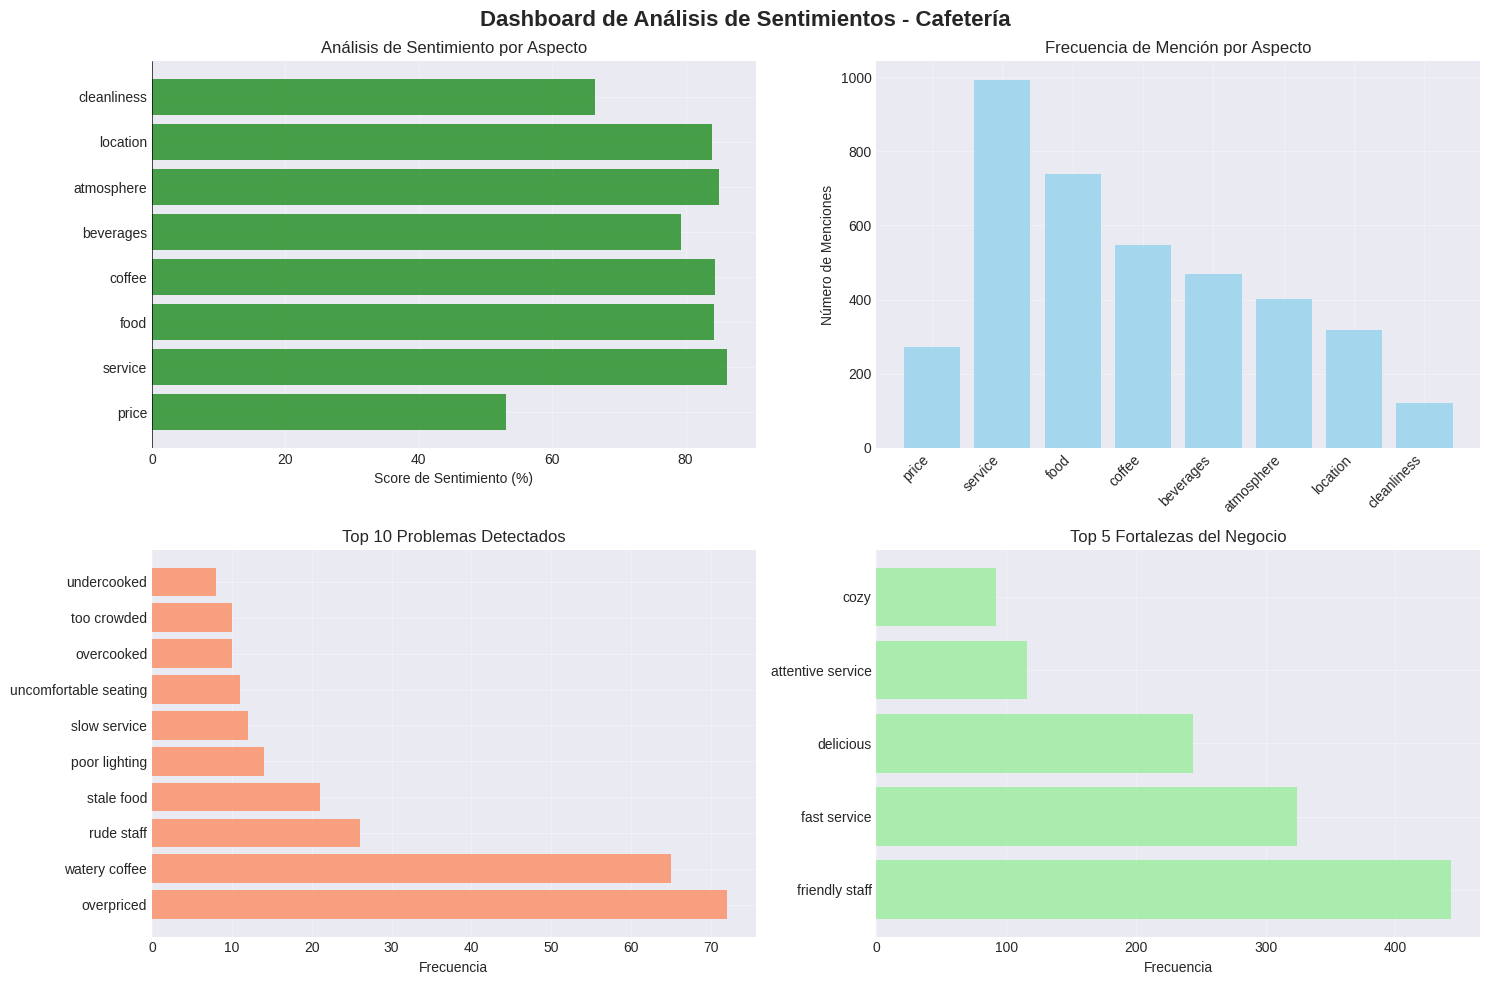

Visualizaciones generadas


In [10]:
# Visualización opcional de los resultados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Crear visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sentimiento por aspecto
aspects = [i['aspect'] for i in insights[:8]]
scores = [i['sentiment_score'] for i in insights[:8]]
colors = ['green' if s > 0 else 'red' for s in scores]

axes[0, 0].barh(aspects, scores, color=colors, alpha=0.7)
axes[0, 0].set_xlabel('Score de Sentimiento (%)')
axes[0, 0].set_title('Análisis de Sentimiento por Aspecto')
axes[0, 0].axvline(x=0, color='black', linewidth=0.5)
axes[0, 0].grid(True, alpha=0.3)

# 2. Total de menciones por aspecto
mentions = [i['total_mentions'] for i in insights[:8]]
axes[0, 1].bar(range(len(aspects)), mentions, color='skyblue', alpha=0.7)
axes[0, 1].set_xticks(range(len(aspects)))
axes[0, 1].set_xticklabels(aspects, rotation=45, ha='right')
axes[0, 1].set_ylabel('Número de Menciones')
axes[0, 1].set_title('Frecuencia de Mención por Aspecto')
axes[0, 1].grid(True, alpha=0.3)

# 3. Top problemas globales
all_problems = Counter()
for stats in aspect_stats.values():
    all_problems.update(stats['problems'])

if all_problems:
    top_problems = all_problems.most_common(10)
    problem_names = [p[0].replace('_', ' ') for p in top_problems]
    problem_counts = [p[1] for p in top_problems]

    axes[1, 0].barh(problem_names, problem_counts, color='coral', alpha=0.7)
    axes[1, 0].set_xlabel('Frecuencia')
    axes[1, 0].set_title('Top 10 Problemas Detectados')
    axes[1, 0].grid(True, alpha=0.3)

# 4. Top fortalezas globales
all_positives = Counter()
for stats in aspect_stats.values():
    all_positives.update(stats['positives'])

if all_positives:
    top_positives = all_positives.most_common(5)
    positive_names = [p[0].replace('_', ' ') for p in top_positives]
    positive_counts = [p[1] for p in top_positives]

    axes[1, 1].barh(positive_names, positive_counts, color='lightgreen', alpha=0.7)
    axes[1, 1].set_xlabel('Frecuencia')
    axes[1, 1].set_title('Top 5 Fortalezas del Negocio')
    axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Dashboard de Análisis de Sentimientos - Cafetería', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Visualizaciones generadas")

## 11. Ver tabla de resultados

In [11]:
# Mostrar tabla de resultados
print("\nTABLA DE INSIGHTS EXPORTADOS:")
print("="*60)
df_export


TABLA DE INSIGHTS EXPORTADOS:


,Categoría,Total_Menciones,Score_Sentimiento,Satisfacción_Positiva,Insatisfacción_Negativa,Opiniones_Neutrales,Polaridad_Promedio,Problemas_Principales,Fortalezas_Destacadas,Prioridad_Acción,Urgencia,Tendencia,Benchmark_Industria,Impacto_ROI,Recomendaciones_Específicas
0,PRICE,271,53.1%,69.7%,16.6%,13.7%,0.276,"Overpriced(72), Poor Value(6), Expensive Coffe...","Good Value(35), Affordable(21), Free Extras(1)...",MEDIA,PREVENTIVO,Estable,En línea con el sector,Retorno medio,ACCIONES ESPECÍFICAS REQUERIDAS: | • Overprice...
1,SERVICE,993,86.2%,90.5%,4.3%,5.1%,0.477,"Rude Staff(26), Slow Service(12), Wrong Order(...","Friendly Staff(443), Fast Service(324), Attent...",BAJA,NO,Mejorando,En línea con el sector,Alto retorno potencial,ACCIONES ESPECÍFICAS REQUERIDAS: | • Rude Staf...
2,FOOD,740,84.3%,88.5%,4.2%,7.3%,0.477,"Stale Food(21), Overcooked(10), Undercooked(8)...","Delicious(244), Authentic(49), Beautiful Prese...",BAJA,NO,Mejorando,En línea con el sector,Retorno medio,ACCIONES ESPECÍFICAS REQUERIDAS: | • Stale Foo...
3,COFFEE,546,84.4%,88.8%,4.4%,6.8%,0.498,"Watery Coffee(65), Burnt Coffee(4), Bad Foam(3...","Excellent Coffee(41), Great Flavor(11), Perfec...",BAJA,NO,Estable,En línea con el sector,Retorno bajo,ACCIONES ESPECÍFICAS REQUERIDAS: | • Watery Co...
4,BEVERAGES,470,79.4%,85.7%,6.4%,7.9%,0.486,"Warm Cold Drinks(2), Bad Tea(1)",Fresh Juices(6),BAJA,NO,Empeorando,10.7% sobre media del sector,Retorno bajo,ACCIONES ESPECÍFICAS REQUERIDAS: | • Warm Cold...
5,ATMOSPHERE,402,85.1%,88.6%,3.5%,8.0%,0.424,"Poor Lighting(14), Uncomfortable Seating(11), ...","Cozy(92), Peaceful(75), Outdoor Seating(58), C...",BAJA,NO,Estable,13.6% sobre media del sector,Retorno bajo,ACCIONES ESPECÍFICAS REQUERIDAS: | • Poor Ligh...
6,LOCATION,317,83.9%,87.7%,3.8%,8.5%,0.385,Hard To Find(6),"Convenient(24), Near Attractions(1), Accessibl...",BAJA,NO,Estable,17.7% sobre media del sector,Retorno bajo,ACCIONES ESPECÍFICAS REQUERIDAS: | • Hard To F...
7,CLEANLINESS,122,66.4%,75.4%,9.0%,15.6%,0.337,Ninguno detectado,Ninguno detectado,BAJA,NO,Mejorando,14.6% bajo media del sector,Retorno bajo,Realizar auditoría completa de cleanliness. Im...
8,TIMING,96,74.0%,79.2%,5.2%,15.6%,0.407,Wrong Hours(1),Convenient Hours(1),BAJA,NO,Mejorando,En línea con el sector,Retorno bajo,ACCIONES ESPECÍFICAS REQUERIDAS: | • Wrong Hou...
9,GENERAL,85,78.8%,84.7%,5.9%,9.4%,0.617,Ninguno detectado,Ninguno detectado,BAJA,NO,Estable,En línea con el sector,Retorno bajo,Realizar auditoría completa de general. Implem...
